# Modelo Stacking: Ensemble tabular + imagen (ResNet/DenseNet/YOLO) con meta-modelo

Este notebook implementa un sistema de **stacking** donde varios modelos base (tabular e imagen) generan **probabilidades por clase**, y un **meta-modelo** aprende a combinarlas para producir la predicción final.

**Componentes del sistema:**
- **Modelos base (nivel 0):**
  - **Tabular:** modelo entrenado con variables tabulares (con `StandardScaler`) que produce $p_{tab}(y\mid x)$.
  - **Imagen:** modelos de visión (p.ej. ResNet18, DenseNet121, YOLO-cls) que producen $p_{img}(y\mid x)$ a partir de las imágenes asociadas.
- **Predicciones OOF (clave del stacking):**
  - Se generan predicciones **out-of-fold** para train con CV estratificada, evitando leakage:
    $$X_{meta}^{OOF} = [p_{tab}^{OOF},\ p_{res}^{OOF},\ p_{den}^{OOF},\ p_{yolo}^{OOF},\dots]$$
- **Meta-modelo (nivel 1):**
  - Un clasificador (p.ej. AdaBoost sobre árboles pequeños) que aprende:
    $$\hat{y} = f_{\text{meta}}(X_{meta})$$

**Intención del enfoque:** mejorar el rendimiento y la robustez combinando fortalezas de cada modalidad, dejando que el meta-modelo aprenda **cuándo confiar** más en tabular o en imagen (y en qué clases), usando OOF para entrenar la combinación sin sobreajuste.


## Install + imports

Prepara el entorno para el pipeline de **stacking** (modelos base + meta-modelo) e importa librerías para tabular, visión, validación cruzada, métricas y guardado de modelos.

**Qué incluye (idea + implementación):**
- **Instalación:** `ultralytics` (YOLO) y `joblib` (persistencia de modelos sklearn).
- **Core:** `numpy/pandas`, utilidades (`os`, `shutil`, etc.), `tqdm` para progreso.
- **Imagen (PyTorch):** `torch`, `torchvision.models/transforms`, `Dataset/DataLoader`, `PIL.Image` para extractores y predicción por imagen.
- **Tabular + stacking (sklearn):**
  - `StratifiedKFold` para OOF,
  - `StandardScaler`,
  - modelos base (`RandomForest`, `LogisticRegression`) y **meta** (`AdaBoost` + `DecisionTree`),
  - métricas (accuracy, F1-macro, kappa, report, confusión).
- **IO/Colab:** `zipfile` y `drive` para gestionar datos y guardar artefactos.


In [ ]:
!pip -q install ultralytics joblib

import os, re, math, random, shutil
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO
import zipfile
from google.colab import drive
print("✅ Imports OK")


✅ Imports OK


## Descarga Datos en local
Para poder trabajar en google colab, se va a bajar el repositorio con la carpeta Datos en `\content`.

In [ ]:
# 1. Montar Drive
drive.mount('/content/drive')

# 2. Rutas
zip_path = '/content/drive/MyDrive/Datos ML/Datos.zip'
extract_path = '/content'  # Descomprimir en la raíz para que coincida con tus rutas esperadas

# 3. Descomprimir
if not os.path.exists(os.path.join(extract_path, 'Datos')):
    print("Descomprimiendo datos...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("¡Descompresión completada!")
else:
    print("La carpeta 'Datos' ya existe.")

Mounted at /content/drive
Descomprimiendo datos...
¡Descompresión completada!


## Configuración general (semillas, rutas y parámetros)

Centraliza la configuración del experimento de stacking: **reproducibilidad**, **dispositivo**, rutas a datos/imágenes, y los hiperparámetros de entrenamiento de los modelos base (CNN y YOLO) y de la CV.

**Qué define (idea + implementación):**
- **Semillas:** fija `SEED` en `random`, `numpy` y `torch` (CPU/GPU) para resultados reproducibles.
- **Device:** `DEVICE` será `cuda` si hay GPU disponible.
- **Rutas:** CSVs (`TRAIN_CSV_PATH`, `TEST_CSV_PATH`) y raíz de imágenes `IMAGES_ROOT`.
- **YOLO base:** ruta al `.pt` inicial (`YOLO26X_PT`) para entrenar/usar YOLO-cls.
- **Parámetros de pipeline:**
  - imagen: `IMG_SIZE`, `MAX_IMAGES`
  - CNN (ResNet/DenseNet): `BATCH_SIZE_CNN`, `EPOCHS_CNN`, `LR_CNN`, `WEIGHT_DECAY`
  - YOLO: `EPOCHS_YOLO`, `BATCH_YOLO`
  - CV: `N_SPLITS=5` para generar OOF
- **Salida:** crea `MODELS_DIR` donde se guardarán checkpoints y artefactos del stacking.


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# Rutas (ajusta a tu caso)
TRAIN_CSV_PATH = "/content/Train_clean.csv"
TEST_CSV_PATH  = "/content/Test_clean.csv"

# Carpeta raíz de imágenes (subcarpetas por clase)
IMAGES_ROOT = "/content/Datos/images/MULTICLASE"

# Pesos iniciales YOLO (tienes el .pt local)
YOLO26X_PT = "/content/yolo26x-cls.pt"   # <-- AJUSTA nombre real

# Hiperparámetros (pipeline)
IMG_SIZE = 224
MAX_IMAGES = 5
BATCH_SIZE_CNN = 16
EPOCHS_CNN = 10           # empieza con 3-5
LR_CNN = 1e-3
WEIGHT_DECAY = 1e-4

EPOCHS_YOLO = 15          # empieza con 3-5
BATCH_YOLO = 32

N_SPLITS = 5

MODELS_DIR = "/content/MODELOS"
os.makedirs(MODELS_DIR, exist_ok=True)
print("✅ Carpeta MODELOS:", MODELS_DIR)


DEVICE: cuda
✅ Carpeta MODELOS: /content/MODELOS


## Carga de datos + tabular prep (multiclase)

Carga `train_df/test_df`, define la etiqueta multiclase y prepara el bloque tabular que se usará como modelo base (y como entrada del meta-modelo).

**Qué hace (idea + implementación):**
- Lee los CSV y verifica que existen `img_id` y `LABEL_COL="diagnostic"`.
- Define `tab_cols` excluyendo IDs/rutas y la propia etiqueta (`EXCLUDE_COLS`), y rellena `NaN` con 0.
- Extrae `y_train/y_test` como enteros y calcula `NUM_CLASSES` + distribución de clases.
- Ajusta `StandardScaler` **solo con train** y transforma train/test:
  - `Xtab_train = fit_transform(train)`
  - `Xtab_test = transform(test)`
- Define `TAB_DIM` como número de features tabulares.


In [ ]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df  = pd.read_csv(TEST_CSV_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Ejemplos img_id:", train_df["img_id"].head(5).tolist())

LABEL_COL = "diagnostic"  # multiclase
assert LABEL_COL in train_df.columns, "No existe diagnostic en Train"
assert "img_id" in train_df.columns, "No existe img_id"

EXCLUDE_COLS = set(["img_id", "patient_id", "lesion_id", "patient_lesion_id", "img_path", LABEL_COL])

tab_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]
print("N tabular cols:", len(tab_cols))
print("Tab cols ejemplo:", tab_cols[:10])

# fillna
train_df[tab_cols] = train_df[tab_cols].fillna(0)
test_df[tab_cols]  = test_df[tab_cols].fillna(0)

y_train = train_df[LABEL_COL].astype(int).values
y_test  = test_df[LABEL_COL].astype(int).values

NUM_CLASSES = len(np.unique(y_train))
print("NUM_CLASSES:", NUM_CLASSES)
print("Distribución Train:", pd.Series(y_train).value_counts().sort_index().to_dict())

# Escalado tabular (usamos solo train para fit)
scaler = StandardScaler()
Xtab_train = scaler.fit_transform(train_df[tab_cols].values.astype(np.float32))
Xtab_test  = scaler.transform(test_df[tab_cols].values.astype(np.float32))

TAB_DIM = Xtab_train.shape[1]
print("Xtab_train:", Xtab_train.shape, "| Xtab_test:", Xtab_test.shape, "| TAB_DIM:", TAB_DIM)


Train shape: (566, 89)
Test shape : (142, 89)
Ejemplos img_id: ['PAT_528_992_124.png', 'PAT_321_682_236.png', 'PAT_684_1302_588.png', 'PAT_100_393_595.png, PAT_100_393_898.png', 'PAT_629_1192_362.png']
N tabular cols: 84
Tab cols ejemplo: ['age', 'fitspatrick', 'diameter_1', 'diameter_2', 'smoke_False', 'smoke_True', 'smoke_Unknown', 'drink_False', 'drink_True', 'drink_Unknown']
NUM_CLASSES: 6
Distribución Train: {0: 115, 1: 117, 2: 29, 3: 104, 4: 96, 5: 105}
Xtab_train: (566, 84) | Xtab_test: (142, 84) | TAB_DIM: 84


## Indexado de imágenes + cobertura

Construye un índice `filename → ruta` para localizar imágenes rápidamente y comprueba la consistencia entre lo que aparece en `img_id` y lo que existe en disco.

**Qué hace (idea + implementación):**
- `parse_img_list`: convierte `img_id` (lista separada por comas) en una lista de filenames y limita a `MAX_IMAGES`.
- Recorre `IMAGES_ROOT` y crea `img_index = {filename: full_path}` para extensiones de imagen comunes.
- Calcula **cobertura** en train/test contando referencias totales vs faltantes (`missing`) y muestra el %.
- Imprime la distribución del nº de imágenes por fila en train (tras aplicar el límite `MAX_IMAGES`).


In [ ]:
def parse_img_list(s, max_images=5):
    if pd.isna(s): return []
    if isinstance(s, str):
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return parts[:max_images]
    return []

# indexado filename -> path
img_index = {}
total = 0
for root, _, files in os.walk(IMAGES_ROOT):
    for f in files:
        if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".webp")):
            total += 1
            img_index[f] = os.path.join(root, f)

print("✅ Total archivos imagen:", total)
print("✅ Total filenames indexados:", len(img_index))

# cobertura
def count_missing(df):
    tot_refs, miss = 0, 0
    for s in df["img_id"].astype(str).values:
        for fn in parse_img_list(s, MAX_IMAGES):
            tot_refs += 1
            if fn not in img_index: miss += 1
    return tot_refs, miss

tr_refs, tr_miss = count_missing(train_df)
te_refs, te_miss = count_missing(test_df)
print(f"Train refs {tr_refs} | missing {tr_miss} | cov {(1-tr_miss/max(1,tr_refs))*100:.2f}%")
print(f"Test  refs {te_refs} | missing {te_miss} | cov {(1-te_miss/max(1,te_refs))*100:.2f}%")

# distribución nº imágenes por fila
print("\n📊 Nº imágenes por fila (Train):")
print(train_df["img_id"].apply(lambda x: len(parse_img_list(x, MAX_IMAGES))).value_counts().sort_index())


✅ Total archivos imagen: 802
✅ Total filenames indexados: 802
Train refs 649 | missing 0 | cov 100.00%
Test  refs 153 | missing 0 | cov 100.00%

📊 Nº imágenes por fila (Train):
img_id
1    495
2     62
3      7
4      1
5      1
Name: count, dtype: int64


## Soft-voting de probabilidades

Define `softvote_probs` para combinar varias predicciones (vectores de probabilidad) haciendo el **promedio**; si no hay predicciones, devuelve una distribución uniforme.


In [ ]:
def softvote_probs(list_of_probs):
    """
    list_of_probs: lista de np.array shape (NUM_CLASSES,)
    devuelve promedio (NUM_CLASSES,)
    """
    if len(list_of_probs) == 0:
        return np.ones(NUM_CLASSES, dtype=np.float32) / NUM_CLASSES
    return np.mean(np.stack(list_of_probs, axis=0), axis=0)

print("✅ soft-voting listo")


✅ soft-voting listo


## Dataset de imagen (ImageOnly) + transforms

Define el preprocesado de imagen para **entrenar** y **evaluar** y crea un `Dataset` que convierte el dataframe en un conjunto de pares `(imagen, etiqueta)`.

**Qué hace (idea + implementación):**
- `img_tf_train`: resize + *data augmentation* (flip horizontal) + normalización ImageNet.
- `img_tf_eval`: resize + normalización (sin augmentación).
- `ImageOnlyDataset`:
  - Expande cada fila del CSV en **muestras por imagen** (si una fila tiene varias `img_id`, genera varias muestras con la misma etiqueta).
  - En `__getitem__` abre la imagen (fallback a imagen dummy si falla), aplica `transform` y devuelve `(x, y)`.


In [ ]:
img_tf_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

img_tf_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class ImageOnlyDataset(Dataset):
    def __init__(self, df_subset, img_index, transform):
        self.samples = []
        for _, row in df_subset.iterrows():
            y = int(row[LABEL_COL])
            for fn in parse_img_list(row["img_id"], MAX_IMAGES):
                if fn in img_index:
                    self.samples.append((img_index[fn], y))
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, y = self.samples[i]
        try:
            im = Image.open(path).convert("RGB")
        except:
            im = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        x = self.transform(im)
        return x, torch.tensor(y, dtype=torch.long)

print("✅ Dataset ImageOnly definido")


✅ Dataset ImageOnly definido


## Builders (ResNet/DenseNet) + entrenamiento de clasificador imagen

Define dos constructores de modelos CNN y una función genérica para entrenarlos y guardar el mejor checkpoint.

**Qué hace (idea + implementación):**
- **`build_resnet18(num_classes)` / `build_densenet121(num_classes)`**
  - Carga el backbone con pesos ImageNet (`Weights.DEFAULT`).
  - Sustituye la última capa (FC / classifier) por una `Linear(..., num_classes)` para adaptar a tus clases.
- **`train_torch_classifier(...)`**
  - Entrena el modelo con `CrossEntropyLoss` y `AdamW(lr, weight_decay)`.
  - Por época: loop de train + loop de validación, calculando `F1-macro`.
  - Guarda el **mejor estado por F1-macro** (`best_state`) y al final:
    - recarga el mejor estado
    - guarda `state_dict` en `save_path`
    - devuelve el modelo listo.


In [ ]:
def build_resnet18(num_classes):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_f = m.fc.in_features
    m.fc = nn.Linear(in_f, num_classes)
    return m

def build_densenet121(num_classes):
    m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_f = m.classifier.in_features
    m.classifier = nn.Linear(in_f, num_classes)
    return m

def train_torch_classifier(model, train_loader, val_loader, epochs, lr, weight_decay, device, save_path):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1 = -1
    best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= max(1, len(train_loader))

        model.eval()
        y_true, y_pred = [], []
        va_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                va_loss += loss.item()
                pred = out.argmax(dim=1)
                y_true.extend(y.cpu().numpy().tolist())
                y_pred.extend(pred.cpu().numpy().tolist())
        va_loss /= max(1, len(val_loader))
        va_f1 = f1_score(y_true, y_pred, average="macro")

        if va_f1 > best_f1:
            best_f1 = va_f1
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            improved = "🏆"
        else:
            improved = ""

        print(f"  Ep {ep:02d}/{epochs} | tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | va_f1 {va_f1:.4f} {improved}")

    model.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    torch.save(model.state_dict(), save_path)
    print("✅ Guardado:", save_path, "| Best va_f1:", best_f1)
    return model


## Preparación y entrenamiento de YOLO-cls por fold

Define utilidades para entrenar un modelo **YOLO de clasificación** dentro de cada fold de la CV, construyendo la estructura de carpetas que Ultralytics espera.

**Qué hace (idea + implementación):**
- **`build_yolo_cls_fold_dir(...)`**
  - Crea `fold_dir/train/<clase>` y `fold_dir/val/<clase>` (clases como `0..NUM_CLASSES-1`).
  - Recorre `df_train_fold/df_val_fold` y, por cada `img_id`, crea **symlinks** a las imágenes dentro de la carpeta de su clase.
  - Así YOLO puede entrenar leyendo un dataset tipo *ImageFolder* sin duplicar archivos físicamente.

- **`train_yolo_cls_on_fold(...)`**
  - Lanza `YOLO(yolo_init_pt).train(...)` usando `fold_dir` como `data` (train/val ya preparados).
  - Busca el `best.pt` generado por Ultralytics dentro del directorio de ejecución (`project/name/.../weights/best.pt`).
  - Copia ese `best.pt` a una ruta final estable (`YOLO_best.pt`) y la devuelve para usarla luego en inferencia/OOF.


In [ ]:
def build_yolo_cls_fold_dir(fold_dir, df_train_fold, df_val_fold, img_index):
    """
    Crea estructura:
    fold_dir/train/0..5
    fold_dir/val/0..5
    con symlinks a imágenes
    """
    if os.path.exists(fold_dir):
        shutil.rmtree(fold_dir)
    os.makedirs(fold_dir, exist_ok=True)

    for split_name, df_split in [("train", df_train_fold), ("val", df_val_fold)]:
        for c in range(NUM_CLASSES):
            os.makedirs(os.path.join(fold_dir, split_name, str(c)), exist_ok=True)

        n_links = 0
        for _, row in df_split.iterrows():
            y = int(row[LABEL_COL])
            for fn in parse_img_list(row["img_id"], MAX_IMAGES):
                if fn in img_index:
                    src = img_index[fn]
                    dst = os.path.join(fold_dir, split_name, str(y), fn)
                    if not os.path.exists(dst):
                        os.symlink(src, dst)
                        n_links += 1

        print(f"  ✅ {split_name} symlinks:", n_links)

print("✅ Función YOLO fold dir lista")


✅ Función YOLO fold dir lista


In [ ]:
def train_yolo_cls_on_fold(fold_dir, yolo_init_pt, epochs, batch, imgsz, device, save_dir_out):
    """
    Entrena YOLO clasificación en fold_dir (train/val) y guarda best.pt.
    """
    yolo = YOLO(yolo_init_pt)
    results = yolo.train(
        data=fold_dir,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        device=0 if device.type=="cuda" else "cpu",
        verbose=False,
        project=save_dir_out,
        name="yolo_train",
        exist_ok=True
    )

    # Ultralytics guarda best.pt en runs/.../weights/best.pt dentro del project/name
    # Vamos a localizarlo:
    run_dir = os.path.join(save_dir_out, "yolo_train")
    best_path = None
    for root, _, files in os.walk(run_dir):
        for f in files:
            if f == "best.pt" and "weights" in root:
                best_path = os.path.join(root, f)

    assert best_path is not None, "No encontré best.pt de YOLO"
    final_best = os.path.join(save_dir_out, "YOLO_best.pt")
    shutil.copy(best_path, final_best)

    print("✅ YOLO best guardado en:", final_best)
    return final_best


## Inferencia por fila (probas de ResNet/DenseNet/YOLO + soft-voting)

Define funciones para obtener, por cada muestra (fila del CSV), un vector de probabilidades por clase a partir de sus imágenes asociadas.

**Qué hace (idea + implementación):**
- **`predict_probs_resnet_densenet(model, img_paths, device)`**
  - Recorre las imágenes de la muestra, aplica `img_tf_eval`, hace `softmax` y promedia las probabilidades con `softvote_probs`.
  - Usa `@torch.no_grad()` y `model.eval()` para inferencia eficiente.
- **`predict_probs_yolo(yolo_model, img_paths)`**
  - Para cada imagen llama a `yolo_model.predict(...)`, extrae `res[0].probs` y promedia con soft-voting.
- **`get_row_img_paths(df, idx)`**
  - Convierte `img_id` en lista de filenames y los mapea a rutas reales usando `img_index`.

Resultado: una forma estándar de producir $p_{res}$, $p_{den}$ o $p_{yolo}$ por muestra (promediando sus imágenes).


In [ ]:
@torch.no_grad()
def predict_probs_resnet_densenet(model, img_paths, device):
    model.eval()
    probs_list = []
    for p in img_paths:
        try:
            im = Image.open(p).convert("RGB")
        except:
            im = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        x = img_tf_eval(im).unsqueeze(0).to(device)
        out = model(x)
        pr = torch.softmax(out, dim=1).squeeze(0).cpu().numpy()
        probs_list.append(pr)
    return softvote_probs(probs_list)

def predict_probs_yolo(yolo_model, img_paths):
    probs_list = []
    for p in img_paths:
        res = yolo_model.predict(source=p, imgsz=IMG_SIZE, verbose=False)
        # res[0].probs.data -> tensor (num_classes,)
        pr = res[0].probs.data.cpu().numpy()
        probs_list.append(pr)
    return softvote_probs(probs_list)

def get_row_img_paths(df, idx):
    fns = parse_img_list(df.loc[idx, "img_id"], MAX_IMAGES)
    paths = [img_index[fn] for fn in fns if fn in img_index]
    return paths

print("✅ Inferencia por fila lista")


✅ Inferencia por fila lista


## Generación OOF para stacking (entrenar bases por fold + construir $X_{meta}^{OOF}$)

Esta celda construye las **meta-features OOF** para el stacking: por cada fold entrena los **5 modelos base** y genera, en el split de validación, las probabilidades por clase que se concatenan en un único vector por muestra.

**Qué hace (idea + implementación):**
- Define `StratifiedKFold` y reserva:
  - `X_meta_oof`: matriz `(N, 5·NUM_CLASSES)` para guardar, por fila de train, las probabilidades OOF de cada modelo base.
  - Orden de concatenación por muestra: **[YOLO | ResNet | DenseNet | LR | RF]**.
- Para cada fold:
  1. **Crea carpeta del fold** (`MODELS_DIR/modelo_multiclase_fold{fold}`) y separa `df_tr/df_va`.
  2. **Entrena modelos tabulares (LR y RF)** con `Xtab_train[tr_idx]` y guarda `LR.pkl` y `RF.pkl`.
  3. **Entrena modelos CNN (ResNet y DenseNet)** con un dataset “image-only” construido desde las imágenes de `tr_idx/va_idx`, y guarda sus pesos (`ResNet18.pth`, `DenseNet121.pth`).
  4. **Entrena YOLO-cls**:
     - crea estructura `train/val/<clase>` mediante symlinks,
     - entrena desde `YOLO26X_PT`,
     - localiza y copia `best.pt` a `YOLO_best.pt`, y lo carga para inferencia.
  5. **Inferencia OOF en `va_idx`**:
     - tabular: precalcula `lr_probs` y `rf_probs`.
     - imagen (por fila): obtiene rutas con `get_row_img_paths` y calcula:
       - `pr_yolo`, `pr_res`, `pr_den` (soft-voting sobre las imágenes de la muestra).
     - concatena las 5 probabilidades y las guarda en `X_meta_oof[va_idx]`.
  6. **Resumen del fold:** calcula F1-macro de cada base en el val (a partir de `argmax` de su bloque) y lo guarda en `fold_summaries`.

**Salida clave:** `X_meta_oof` queda rellena con predicciones OOF (sin leakage) y lista para entrenar el **meta-modelo** de stacking.


In [ ]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Guardaremos aquí OOF features
X_meta_oof = np.zeros((len(train_df), NUM_CLASSES * 5), dtype=np.float32)  # 5 modelos base
y_oof = y_train.copy()

fold_summaries = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(train_df)), y_train), start=1):
    print("\n" + "="*70)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("="*70)

    fold_dir = os.path.join(MODELS_DIR, f"modelo_multiclase_fold{fold}")
    os.makedirs(fold_dir, exist_ok=True)
    print("📁 Guardando en:", fold_dir)

    df_tr = train_df.iloc[tr_idx].reset_index(drop=False)  # guardamos index original en 'index'
    df_va = train_df.iloc[va_idx].reset_index(drop=False)

    # -----------------------
    # 1) TABULAR MODELS (LR, RF)
    # -----------------------
    Xtr_tab, ytr = Xtab_train[tr_idx], y_train[tr_idx]
    Xva_tab, yva = Xtab_train[va_idx], y_train[va_idx]

    lr = LogisticRegression(max_iter=2000, multi_class="multinomial", n_jobs=-1)
    lr.fit(Xtr_tab, ytr)

    rf = RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1)
    rf.fit(Xtr_tab, ytr)

    joblib.dump(lr, os.path.join(fold_dir, "LR.pkl"))
    joblib.dump(rf, os.path.join(fold_dir, "RF.pkl"))
    print("✅ Guardados LR y RF")

    # -----------------------
    # 2) RESNET / DENSENET (entrenamiento visión)
    # -----------------------
    ds_tr_img = ImageOnlyDataset(train_df.iloc[tr_idx], img_index, img_tf_train)
    ds_va_img = ImageOnlyDataset(train_df.iloc[va_idx], img_index, img_tf_eval)

    dl_tr_img = DataLoader(ds_tr_img, batch_size=BATCH_SIZE_CNN, shuffle=True, num_workers=2, drop_last=True)
    dl_va_img = DataLoader(ds_va_img, batch_size=BATCH_SIZE_CNN, shuffle=False, num_workers=2)

    print("🖼️  Image-only train size:", len(ds_tr_img), "| val size:", len(ds_va_img))

    resnet = build_resnet18(NUM_CLASSES)
    resnet_path = os.path.join(fold_dir, "ResNet18.pth")
    print("🚀 Entrenando ResNet18...")
    resnet = train_torch_classifier(resnet, dl_tr_img, dl_va_img, EPOCHS_CNN, LR_CNN, WEIGHT_DECAY, DEVICE, resnet_path)

    densenet = build_densenet121(NUM_CLASSES)
    densenet_path = os.path.join(fold_dir, "DenseNet121.pth")
    print("🚀 Entrenando DenseNet121...")
    densenet = train_torch_classifier(densenet, dl_tr_img, dl_va_img, EPOCHS_CNN, LR_CNN, WEIGHT_DECAY, DEVICE, densenet_path)

    # -----------------------
    # 3) YOLO (clasificación)
    # -----------------------
    yolo_fold_data = os.path.join(fold_dir, "YOLO_DATA")
    print("📦 Construyendo dataset YOLO (symlinks)...")
    build_yolo_cls_fold_dir(yolo_fold_data, train_df.iloc[tr_idx], train_df.iloc[va_idx], img_index)

    print("🚀 Entrenando YOLO...")
    yolo_best_path = train_yolo_cls_on_fold(
        fold_dir=yolo_fold_data,
        yolo_init_pt=YOLO26X_PT,
        epochs=EPOCHS_YOLO,
        batch=BATCH_YOLO,
        imgsz=IMG_SIZE,
        device=DEVICE,
        save_dir_out=os.path.join(fold_dir, "YOLO_RUNS")
    )

    # cargamos YOLO best para inferencia
    yolo_model = YOLO(yolo_best_path)

    # -----------------------
    # 4) OOF INFERENCE sobre va_idx (por fila, soft-voting en multiimagen)
    # -----------------------
    print("🔮 Generando predicciones OOF en fold-val...")
    oof_feats = np.zeros((len(va_idx), NUM_CLASSES * 5), dtype=np.float32)

    # precompute tabular probs
    lr_probs = lr.predict_proba(Xva_tab)   # (n_val, C)
    rf_probs = rf.predict_proba(Xva_tab)   # (n_val, C)

    for j, original_idx in enumerate(tqdm(va_idx)):
        img_paths = get_row_img_paths(train_df, original_idx)

        pr_yolo = predict_probs_yolo(yolo_model, img_paths)
        pr_res  = predict_probs_resnet_densenet(resnet, img_paths, DEVICE)
        pr_den  = predict_probs_resnet_densenet(densenet, img_paths, DEVICE)

        pr_lr = lr_probs[j]
        pr_rf = rf_probs[j]

        # concatenación: [YOLO|RES|DEN|LR|RF]
        oof_feats[j] = np.concatenate([pr_yolo, pr_res, pr_den, pr_lr, pr_rf], axis=0)

    # guardar en la matriz global (en sus posiciones originales)
    X_meta_oof[va_idx] = oof_feats

    # resumen fold rápido (macro f1 de cada base en el val)
    yva_true = y_train[va_idx]
    pred_yolo = np.argmax(oof_feats[:, 0:NUM_CLASSES], axis=1)
    pred_res  = np.argmax(oof_feats[:, NUM_CLASSES:2*NUM_CLASSES], axis=1)
    pred_den  = np.argmax(oof_feats[:, 2*NUM_CLASSES:3*NUM_CLASSES], axis=1)
    pred_lr   = np.argmax(oof_feats[:, 3*NUM_CLASSES:4*NUM_CLASSES], axis=1)
    pred_rf   = np.argmax(oof_feats[:, 4*NUM_CLASSES:5*NUM_CLASSES], axis=1)

    summ = {
        "fold": fold,
        "F1_yolo": f1_score(yva_true, pred_yolo, average="macro"),
        "F1_res":  f1_score(yva_true, pred_res,  average="macro"),
        "F1_den":  f1_score(yva_true, pred_den,  average="macro"),
        "F1_lr":   f1_score(yva_true, pred_lr,   average="macro"),
        "F1_rf":   f1_score(yva_true, pred_rf,   average="macro"),
    }
    fold_summaries.append(summ)
    print("📌 Fold summary:", summ)

print("\n✅ OOF dataset construido.")
print("X_meta_oof shape:", X_meta_oof.shape)
print("Ejemplo fila meta-features (primeras 10):", X_meta_oof[0, :10])
print("\nResumen folds:")
pd.DataFrame(fold_summaries)



FOLD 1/5
📁 Guardando en: /content/MODELOS/modelo_multiclase_fold1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Guardados LR y RF
🖼️  Image-only train size: 521 | val size: 128
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]


🚀 Entrenando ResNet18...
  Ep 01/10 | tr_loss 1.8118 | va_loss 2.9340 | va_f1 0.2188 🏆
  Ep 02/10 | tr_loss 1.3545 | va_loss 1.9190 | va_f1 0.2212 🏆
  Ep 03/10 | tr_loss 1.2946 | va_loss 1.3102 | va_f1 0.4767 🏆
  Ep 04/10 | tr_loss 1.1832 | va_loss 1.7755 | va_f1 0.3376 
  Ep 05/10 | tr_loss 1.1634 | va_loss 1.7365 | va_f1 0.3757 
  Ep 06/10 | tr_loss 1.0589 | va_loss 1.5555 | va_f1 0.4376 
  Ep 07/10 | tr_loss 1.0013 | va_loss 1.4536 | va_f1 0.4379 
  Ep 08/10 | tr_loss 0.8916 | va_loss 2.4416 | va_f1 0.2430 
  Ep 09/10 | tr_loss 0.9228 | va_loss 2.3577 | va_f1 0.1605 
  Ep 10/10 | tr_loss 0.7906 | va_loss 1.7043 | va_f1 0.3394 
✅ Guardado: /content/MODELOS/modelo_multiclase_fold1/ResNet18.pth | Best va_f1: 0.4766746913878121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

      15/15      5.85G     0.1954          7        224: 100% ━━━━━━━━━━━━ 17/17 7.3it/s 2.3s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 40.3it/s 0.1s
                   all      0.531      0.992

15 epochs completed in 0.019 hours.
Optimizer stripped from /content/MODELOS/modelo_multiclase_fold5/YOLO_RUNS/yolo_train/weights/last.pt, 57.0MB
Optimizer stripped from /content/MODELOS/modelo_multiclase_fold5/YOLO_RUNS/yolo_train/weights/best.pt, 57.0MB

Validating /content/MODELOS/modelo_multiclase_fold5/YOLO_RUNS/yolo_train/weights/best.pt...
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO26x-cls summary (fused): 94 layers, 28,340,102 parameters, 0 gradients, 110.3 GFLOPs
train: /content/MODELOS/modelo_multiclase_fold5/YOLO_DATA/train... found 519 images in 6 classes ✅ 
val: /content/MODELOS/modelo_multiclase_fold5/YOLO_DATA/val... found 130 images in 6 classes ✅ 
test: None...
               classes   top1_acc   

  0%|          | 0/113 [00:00<?, ?it/s]

📌 Fold summary: {'fold': 5, 'F1_yolo': 0.5795244192800584, 'F1_res': 0.49038655414245036, 'F1_den': 0.4997518336623494, 'F1_lr': 0.7418195331238809, 'F1_rf': 0.75817627402688}

✅ OOF dataset construido.
X_meta_oof shape: (566, 30)
Ejemplo fila meta-features (primeras 10): [     0.1577    0.076277  0.00047972   0.0091487     0.75613  0.00026107     0.39162     0.20626   0.0024815    0.028925]

Resumen folds:


,fold,F1_yolo,F1_res,F1_den,F1_lr,F1_rf
0,1,0.576638,0.506446,0.416087,0.740740,0.681744
1,2,0.517380,0.467789,0.352356,0.656848,0.688937
2,3,0.556860,0.356449,0.420448,0.684328,0.718724
3,4,0.595846,0.401759,0.432659,0.607703,0.601839
4,5,0.579524,0.490387,0.499752,0.741820,0.758176


## Entrenamiento del meta-modelo (AdaBoost) + guardado

Entrena el **modelo de nivel 1** del stacking usando como entrada las meta-features OOF (`X_meta_oof`) y guarda tanto el meta-modelo como el `scaler` tabular para reproducir el pipeline.

**Qué hace (idea + implementación):**
- Crea `meta_dir = MODELS_DIR/META` para almacenar artefactos finales.
- Define `meta` como **AdaBoost** con estimador base `DecisionTreeClassifier(max_depth=2)` (árboles pequeños) y parámetros (`n_estimators`, `learning_rate`, `SEED`).
- Entrena el meta-modelo con:
  - `meta.fit(X_meta_oof, y_oof)`
- Guarda:
  - `Meta_AdaBoost.pkl` (meta-modelo)
  - `TabularScaler.pkl` (escalador del bloque tabular)
- Hace una **evaluación interna OOF** (indicativa) calculando `oof_pred = meta.predict(X_meta_oof)` y reporta `Accuracy` y `F1-macro`.


In [ ]:
meta_dir = os.path.join(MODELS_DIR, "META")
os.makedirs(meta_dir, exist_ok=True)

meta = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=SEED),
    n_estimators=300,
    learning_rate=0.5,
    random_state=SEED
)

print("🚀 Entrenando meta-modelo (AdaBoost) con OOF...")
meta.fit(X_meta_oof, y_oof)

joblib.dump(meta, os.path.join(meta_dir, "Meta_AdaBoost.pkl"))
joblib.dump(scaler, os.path.join(meta_dir, "TabularScaler.pkl"))

print("✅ Meta-model y scaler guardados en:", meta_dir)

# Eval interna OOF (aprox de generalización)
oof_pred = meta.predict(X_meta_oof)
print("OOF Accuracy:", accuracy_score(y_oof, oof_pred))
print("OOF F1-macro:", f1_score(y_oof, oof_pred, average="macro"))


🚀 Entrenando meta-modelo (AdaBoost) con OOF...
✅ Meta-model y scaler guardados en: /content/MODELOS/META
OOF Accuracy: 0.7950530035335689
OOF F1-macro: 0.8164779980025975


## Inferencia en test del stacking (promedio entre folds + meta-modelo)

Ejecuta la **predicción final** del sistema de stacking en el conjunto de test: carga los modelos entrenados por fold, construye `X_meta_test` (probabilidades concatenadas) y aplica el **meta-modelo AdaBoost** para obtener la clase final.

**Qué hace (idea + implementación):**
- **Carga el meta-modelo** (`Meta_AdaBoost.pkl`) y define `class_names`.
- **Carga modelos base por fold** (`fold_models`):
  - Tabular: `LR.pkl` y `RF.pkl`
  - Imagen: `ResNet18.pth`, `DenseNet121.pth` (se reconstruyen con `build_*` y se cargan pesos)
  - YOLO: carga `YOLO_best.pt`
- **Construcción de $X_{meta}^{test}$** con dimensión `(N_test, 5·NUM_CLASSES)`:
  - **Tabular (LR/RF):** calcula `predict_proba(Xtab_test)` en cada fold y promedia entre folds para obtener `pr_lr` y `pr_rf` estables.
  - **Imagen (YOLO/ResNet/DenseNet):** para cada fila:
    - obtiene `img_paths` con `get_row_img_paths`
    - calcula probabilidades por fold (con soft-voting sobre las imágenes de la muestra)
    - promedia entre folds para obtener `pr_yolo`, `pr_res`, `pr_den`
  - Concatena en orden **[YOLO | RES | DEN | LR | RF]** y lo guarda en `X_meta_test[i]`.
- **Predicción final:** `y_pred = meta.predict(X_meta_test)`.
- **Evaluación:** reporta `Accuracy`, `Kappa`, `F1-macro`, imprime `classification_report` y dibuja la matriz de confusión.

Resultado: evaluación completa del stacking sobre test usando ensamble por folds + meta-modelo.


✅ Modelos de folds cargados: 5
✅ Tabular probs (LR/RF) promediadas entre folds
🔮 Inferencia test (softvote por fila + promedio entre folds)...


  0%|          | 0/142 [00:00<?, ?it/s]

STACKING TEST RESULTS (AdaBoost meta)
Accuracy: 0.7113
Kappa   : 0.6476
F1-macro: 0.7324
------------------------------------------------------------

Classification report:
              precision    recall  f1-score   support

         ACK     1.0000    0.8966    0.9455        29
         BCC     0.6250    0.3333    0.4348        30
         MEL     1.0000    0.8571    0.9231         7
         NEV     0.6857    0.9231    0.7869        26
         SCC     0.4737    0.7500    0.5806        24
         SEK     0.8095    0.6538    0.7234        26

    accuracy                         0.7113       142
   macro avg     0.7657    0.7357    0.7324       142
weighted avg     0.7394    0.7113    0.7051       142



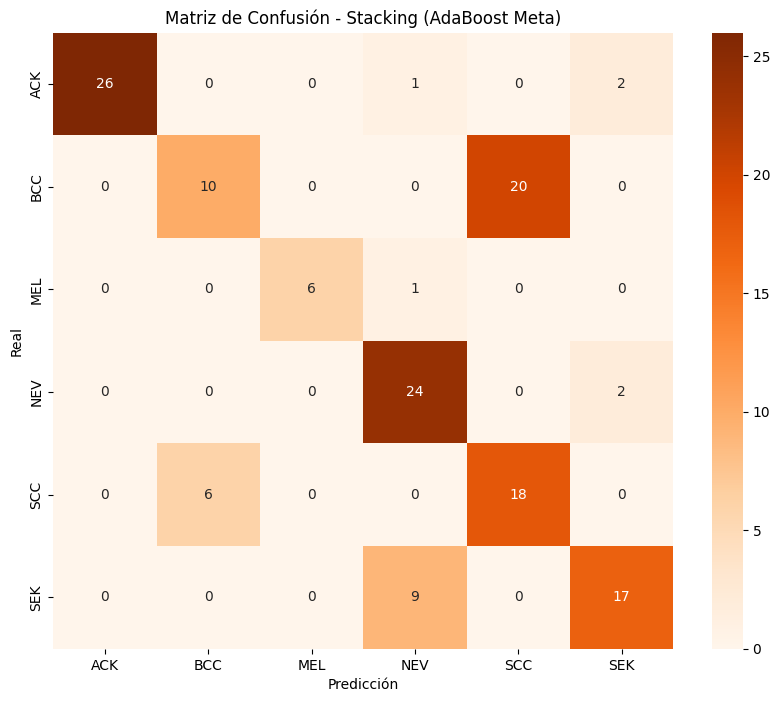

In [ ]:
class_names = ["ACK","BCC","MEL","NEV","SCC","SEK"]

meta = joblib.load(os.path.join(MODELS_DIR, "META", "Meta_AdaBoost.pkl"))

# Cargar modelos por fold
fold_models = []
for fold in range(1, N_SPLITS+1):
    fold_dir = os.path.join(MODELS_DIR, f"modelo_multiclase_fold{fold}")
    lr = joblib.load(os.path.join(fold_dir, "LR.pkl"))
    rf = joblib.load(os.path.join(fold_dir, "RF.pkl"))

    res = build_resnet18(NUM_CLASSES).to(DEVICE)
    res.load_state_dict(torch.load(os.path.join(fold_dir, "ResNet18.pth"), map_location="cpu"))
    res.eval()

    den = build_densenet121(NUM_CLASSES).to(DEVICE)
    den.load_state_dict(torch.load(os.path.join(fold_dir, "DenseNet121.pth"), map_location="cpu"))
    den.eval()

    yolo_best = os.path.join(fold_dir, "YOLO_RUNS", "YOLO_best.pt")
    yolo = YOLO(yolo_best)

    fold_models.append((lr, rf, res, den, yolo))

print("✅ Modelos de folds cargados:", len(fold_models))

# Construir X_meta_test
X_meta_test = np.zeros((len(test_df), NUM_CLASSES*5), dtype=np.float32)

# tabular probs por fold (rápido)
tab_probs_lr = []
tab_probs_rf = []
for (lr, rf, _, _, _) in fold_models:
    tab_probs_lr.append(lr.predict_proba(Xtab_test))
    tab_probs_rf.append(rf.predict_proba(Xtab_test))
tab_probs_lr = np.mean(np.stack(tab_probs_lr, axis=0), axis=0)  # (N,C)
tab_probs_rf = np.mean(np.stack(tab_probs_rf, axis=0), axis=0)  # (N,C)

print("✅ Tabular probs (LR/RF) promediadas entre folds")

print("🔮 Inferencia test (softvote por fila + promedio entre folds)...")
for i in tqdm(range(len(test_df))):
    img_paths = get_row_img_paths(test_df, i)

    # acumulamos probs por fold y promediamos
    probs_yolo_f = []
    probs_res_f  = []
    probs_den_f  = []

    for (_, _, res, den, yolo) in fold_models:
        probs_yolo_f.append(predict_probs_yolo(yolo, img_paths))
        probs_res_f.append(predict_probs_resnet_densenet(res, img_paths, DEVICE))
        probs_den_f.append(predict_probs_resnet_densenet(den, img_paths, DEVICE))

    pr_yolo = np.mean(np.stack(probs_yolo_f, axis=0), axis=0)
    pr_res  = np.mean(np.stack(probs_res_f,  axis=0), axis=0)
    pr_den  = np.mean(np.stack(probs_den_f,  axis=0), axis=0)

    pr_lr = tab_probs_lr[i]
    pr_rf = tab_probs_rf[i]

    X_meta_test[i] = np.concatenate([pr_yolo, pr_res, pr_den, pr_lr, pr_rf], axis=0)

# Predicción final
y_pred = meta.predict(X_meta_test)

acc = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("="*60)
print("STACKING TEST RESULTS (AdaBoost meta)")
print("="*60)
print(f"Accuracy: {acc:.4f}")
print(f"Kappa   : {kappa:.4f}")
print(f"F1-macro: {f1m:.4f}")
print("-"*60)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(class_names))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Stacking (AdaBoost Meta)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


## Importancias del meta-modelo

Analiza qué **bloques** y **clases** pesan más en la decisión del meta-modelo (AdaBoost) usando sus `feature_importances_`.

**Qué hace (idea + implementación):**
- Extrae `importances = meta.feature_importances_`, una importancia por cada feature de `X_meta` (tamaño `5·NUM_CLASSES`).
- Construye etiquetas legibles por feature siguiendo el orden de concatenación:
  - `YOLO_*`, `RESNET_*`, `DENSENET_*`, `LR_*`, `RF_*` para cada clase.
- Crea `imp_df` ordenado de mayor a menor e imprime el **Top-20**.
- Dibuja un barplot horizontal con las 20 importancias más altas para visualizar qué probabilidades (modelo+clase) influyen más en el meta-modelo.


         feature  importance
25        RF_BCC    0.265115
24        RF_ACK    0.123762
29        RF_SEK    0.084349
26        RF_MEL    0.078152
27        RF_NEV    0.072876
28        RF_SCC    0.070885
22        LR_SCC    0.039647
4       YOLO_SCC    0.037763
2       YOLO_MEL    0.032735
14  DENSENET_MEL    0.031815
3       YOLO_NEV    0.029845
18        LR_ACK    0.024802
16  DENSENET_SCC    0.019211
20        LR_MEL    0.016210
0       YOLO_ACK    0.014343
5       YOLO_SEK    0.008903
7     RESNET_BCC    0.007164
21        LR_NEV    0.006581
8     RESNET_MEL    0.006429
23        LR_SEK    0.006225


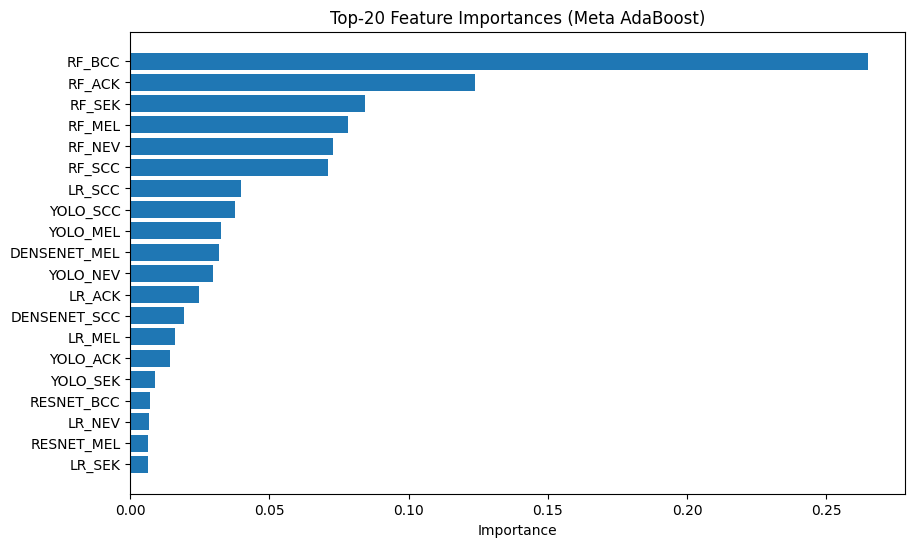

In [ ]:
# --- CELDA EXTRA: IMPORTANCIAS ---

importances = meta.feature_importances_  # shape (NUM_CLASSES*5,)
labels = []
blocks = ["YOLO","RESNET","DENSENET","LR","RF"]
for b in blocks:
    for c in class_names:
        labels.append(f"{b}_{c}")

imp_df = pd.DataFrame({"feature": labels, "importance": importances}).sort_values("importance", ascending=False)
print(imp_df.head(20))

plt.figure(figsize=(10,6))
plt.barh(imp_df["feature"].head(20)[::-1], imp_df["importance"].head(20)[::-1])
plt.title("Top-20 Feature Importances (Meta AdaBoost)")
plt.xlabel("Importance")
plt.show()
